# Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load Data

In [46]:
df = pd.read_csv("../data/ethiopia.csv")  # replace with your file
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


# Add Country Column

In [47]:
df["Country"] = "Ethiopia"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


# Convert the YEAR and DOY columns into datetime column

In [48]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.drop(columns=["YEAR", "DOY"], inplace=True)
df.rename(columns={"date": "YEAR"}, inplace=True)
df.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR
0,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01
1,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02
2,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03
3,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04
4,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05


# Extract Month

In [49]:
df["month"] = df["YEAR"].dt.month
df.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR,month
0,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


# Replace all occurrences of -999 with np.nan

In [50]:
df = df.replace(-999, np.nan)

In [51]:
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

Number of duplicate rows: 0
Empty DataFrame
Columns: [T2M, T2M_MAX, T2M_MIN, T2M_RANGE, PRECTOTCORR, RH2M, WS2M, WS2M_MAX, PS, QV2M, Country, YEAR, month]
Index: []


In [54]:
df.describe(include="number")

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,month
count,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,6.423564
std,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,3.477046
min,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,1.000000
25%,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,3.000000
50%,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,6.000000
75%,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,9.000000
max,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,12.000000


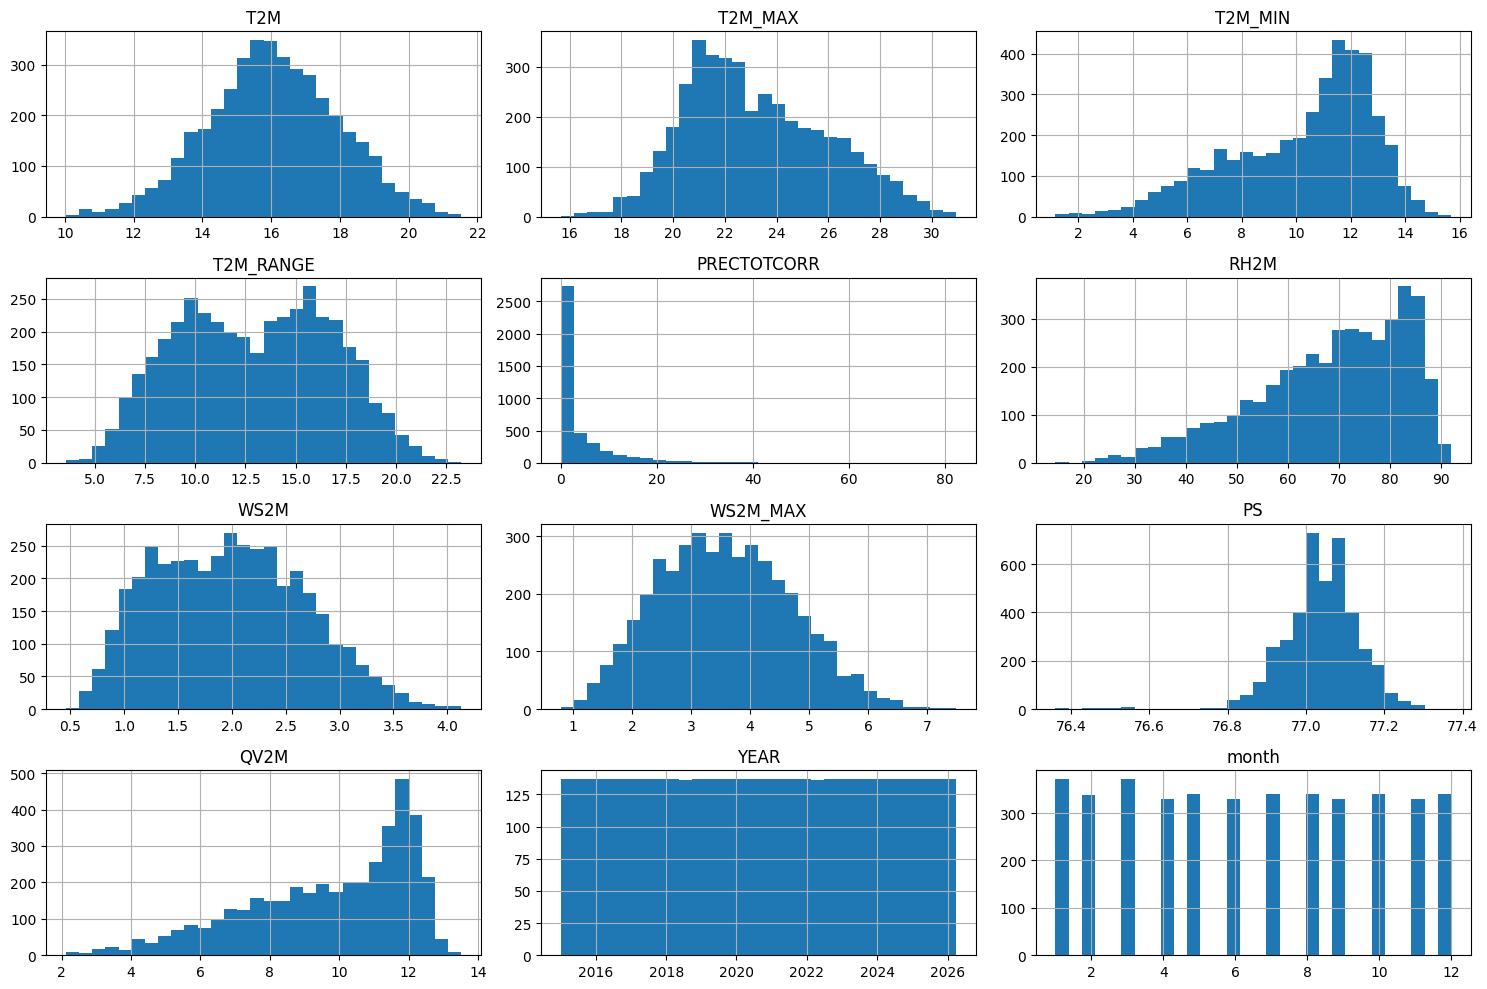

In [61]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

###  Insights 

- Temperature variables (T2M, T2M_MAX, T2M_MIN) show approximately normal distributions, indicating stable and consistent climate behavior over time.
- PRECTOTCORR (precipitation) is highly right-skewed, meaning most days have little or no rainfall, while a few extreme rainfall events dominate the distribution.
- Humidity (RH2M) shows moderate spread, suggesting seasonal variation in atmospheric moisture.
- Wind speed (WS2M) is concentrated at lower values, indicating generally calm wind conditions.
- Pressure (PS) appears very tightly distributed, confirming highly stable atmospheric pressure conditions.

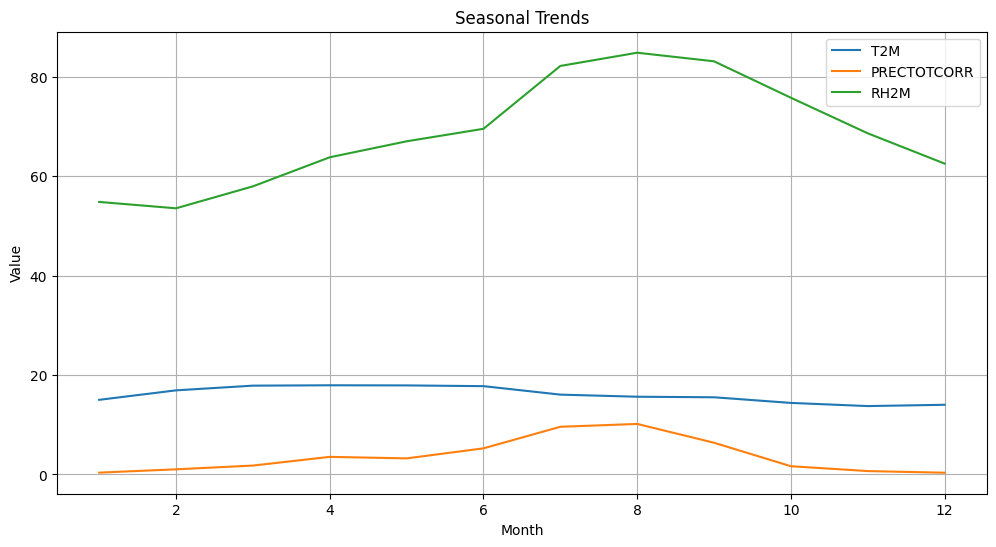

In [63]:
monthly_avg = df.groupby("month").mean(numeric_only=True)

monthly_avg[["T2M", "PRECTOTCORR", "RH2M"]].plot(figsize=(12, 6))
plt.title("Seasonal Trends")
plt.xlabel("Month")
plt.ylabel("Value")
plt.grid()
plt.show()

### Insights from Seasonal Trends

- Temperature (T2M) shows mild seasonal variation, increasing slightly during warmer months and decreasing in cooler periods.
- Precipitation shows clear seasonality, with distinct wet and dry periods across the year.
- Humidity closely follows rainfall patterns, increasing during rainy months and decreasing during dry months.
- Wind speed and pressure remain relatively stable throughout the year, indicating limited seasonal influence.
- Overall, the dataset reflects a strong seasonal rainfall-driven climate pattern.

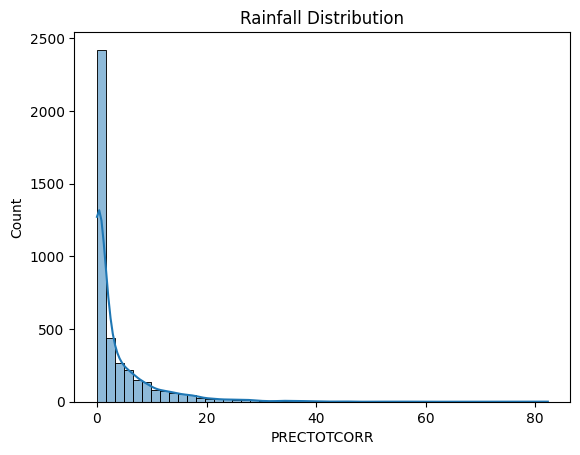

In [64]:
sns.histplot(df["PRECTOTCORR"], bins=50, kde=True)
plt.title("Rainfall Distribution")
plt.show()

###  Insights from Rainfall Distribution

- The distribution is heavily right-skewed, confirming that most days experience little to no rainfall.
- A small number of extreme rainfall events significantly influence the average precipitation.
- This suggests the presence of seasonal storms or concentrated rainy periods rather than evenly distributed rainfall.

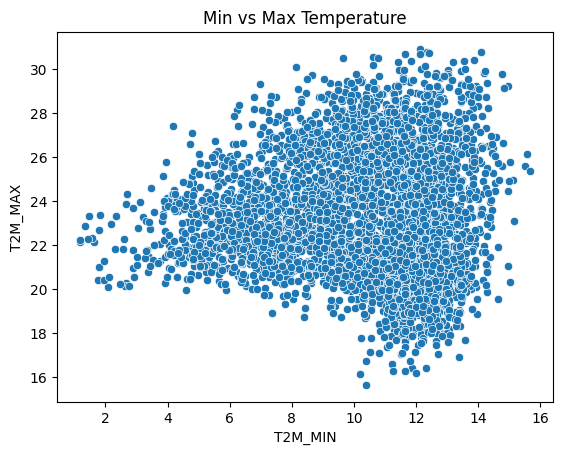

In [65]:
sns.scatterplot(x=df["T2M_MIN"], y=df["T2M_MAX"])
plt.title("Min vs Max Temperature")
plt.show()

###  Insights from Temperature Relationship

- There is a strong positive relationship between minimum and maximum daily temperatures.
- The spread between T2M_MIN and T2M_MAX indicates consistent diurnal temperature variation.
- No extreme anomalies are observed, suggesting stable temperature behavior throughout the dataset period.

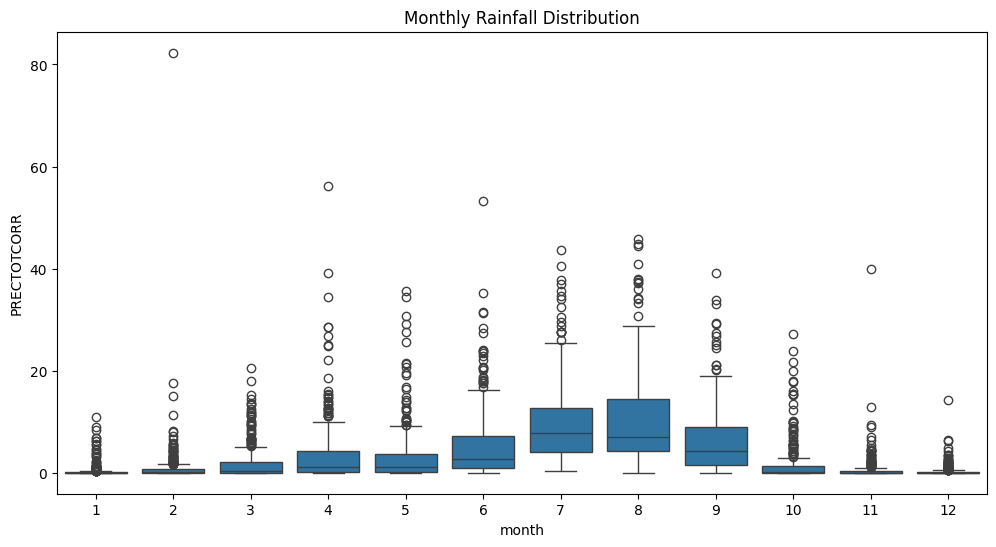

In [66]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="month", y="PRECTOTCORR", data=df)
plt.title("Monthly Rainfall Distribution")
plt.show()

## Key Takeaways

The dataset shows a moderate climate with an average temperature of ~16°C and significant daily temperature variation (~13°C). Precipitation is highly skewed, with many dry days and occasional extreme rainfall events (up to 82 mm), indicating seasonal rainfall patterns. Humidity varies widely, suggesting changing atmospheric conditions across time. Wind speeds are generally low, while atmospheric pressure remains stable, indicating consistent elevation or weather conditions. The dataset appears complete with no missing values.

In [58]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
YEAR           0
month          0
dtype: int64

In [60]:
missing_percent = (df.isna().sum() / len(df)) * 100
high_missing = missing_percent[missing_percent > 5]
high_missing

Series([], dtype: float64)

### ⚠️ Interpretation of Missing Data (>5%)

Columns with **more than 5% missing values** may indicate issues in **data collection, sensor failure, or incomplete records**.

#### 📌 Key implications:
- Missing **precipitation data** could bias rainfall analysis and lead to incorrect conclusions about wet and dry seasons.
- Missing **temperature values** may distort seasonal trends and affect climate pattern interpretation.
- Missing **humidity or wind data** can reduce the reliability of atmospheric condition analysis.

#### 🛠️ Recommended handling:
- **Imputation** (mean, median, interpolation) for moderate missingness
- **Removal** if the column is not critical or has excessive missing data
- **Careful evaluation** before deciding, based on the importance of the variable in analysis or modeling

Overall, columns with high missingness should be treated carefully to avoid introducing bias into the analysis.

# Outlier Detection & Basic Cleaning

### Compute Z-scores

In [114]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
# Compute Z-scores
z_scores = df[cols].apply(stats.zscore)
z_scores

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-2.286045,-0.163269,-2.603645,-0.577866,-1.806604,1.088524,1.330345
1,-1.985701,0.294724,-2.354311,-0.577866,-2.383500,0.595061,0.547137
2,-1.885586,0.352882,-2.400342,-0.577866,-2.346850,-0.304782,-0.725576
3,-1.047782,0.211122,-1.276418,-0.577866,-2.006821,-1.611007,-2.042790
4,-1.058320,-0.017874,-1.115310,-0.577866,-1.448251,-0.928867,-1.277382
...,...,...,...,...,...,...,...
4103,0.485557,0.396500,0.603181,0.260198,0.370666,-0.275755,-0.431873
4104,-0.410208,-1.315520,0.710587,0.449439,0.844399,-1.233653,-1.090480
4105,0.111443,-0.312298,0.560986,0.937648,0.648255,-0.986922,-1.054880
4106,0.838594,0.767256,0.326995,-0.442695,0.031995,0.058058,0.200033


### Flag rows where |Z| > 3

In [ ]:
# Flag rows where |Z| > 3 in ANY column
outlier_mask = (z_scores.abs() > 3).any(axis=1)
outlier_rows = df[outlier_mask]

# outlier_rows.to_csv("../data/outliers.csv", index=False)

### Count how many rows contain at least one outlier

In [ ]:
outlier_counts = (z_scores.abs() > 3).sum()
outlier_counts

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

In [ ]:
# Summary report
print("*** Z-Score Outlier Report ***\n")
print("Outliers per column:")
print(outlier_counts.to_string())
print(f"\nTotal rows flagged (outlier in ANY column): {outlier_mask.sum()}")
print(f"Percentage of dataset flagged: {outlier_mask.sum() / len(df) * 100:.2f}%")
print(f"\nFlagged rows preview:")
print(outlier_rows[cols].head(10))

*** Z-Score Outlier Report ***

Outliers per column:
T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5

Total rows flagged (outlier in ANY column): 132
Percentage of dataset flagged: 3.21%

Flagged rows preview:
       T2M  T2M_MAX  T2M_MIN  PRECTOTCORR   RH2M  WS2M  WS2M_MAX
144  18.45    24.94    14.15        29.07  68.37  1.52      3.07
145  17.60    23.52    13.22        34.38  75.91  1.66      3.53
177  15.79    19.03    13.33        23.89  83.89  1.81      3.03
214  15.97    21.06    12.58        23.46  84.73  1.58      2.55
556  15.20    18.00    12.89        25.19  85.47  1.33      2.99
561  15.22    19.69    10.90        27.65  85.45  1.10      2.41
682  10.08    20.11     2.10         0.00  48.56  2.56      4.45
683  10.46    20.42     1.76         0.00  60.46  2.25      4.16
703  11.49    20.54     4.31         0.00  49.60  3.78      7.18
704  10.28    20.43     1.95         0.00  48.36  3.22      6.

### Outlier Handling Decision (Integrated Analysis)

Outliers were evaluated using both **summary statistics (`df.describe()`)** and **Z-score analysis (|Z| > 3)**.

---

###  Outlier Overview

- Total rows flagged: **132 out of 4108**
- Percentage of dataset: **3.21%**

#### Outliers per column:
- T2M: 3  
- T2M_MAX: 0  
- T2M_MIN: 18  
- PRECTOTCORR: 95  
- RH2M: 13  
- WS2M: 3  
- WS2M_MAX: 5  

Most outliers are concentrated in **PRECTOTCORR (precipitation)**.

---

###  Precipitation Analysis (PRECTOTCORR)

- Mean = 3.63 mm vs Max = 82.30 mm  
- Median = 0.82 mm → much lower than mean  
- 95 outliers (~73% of all flagged rows)

 Indicates:
- Strong **right-skewed distribution**
- Extreme values correspond to **heavy rainfall events**
- Preview rows show rainfall between ~23–34 mm, which are **high but realistic**

Conclusion: These are **valid extreme weather events**, not errors

---

###  Temperature Analysis

- T2M outliers: only 3  
- T2M_MIN outliers: 18  
- Values still fall within realistic environmental bounds (1.17°C – 30.93°C)

Example:
- Very low T2M_MIN (~1–2°C) → likely **cold nights**, not anomalies

Conclusion: Temperature outliers reflect **natural variability**

---

###  Humidity (RH2M)

- 13 outliers  
- Range: 14% → 91%

Wide variation consistent with changing weather conditions

---

### Wind Speed (WS2M, WS2M_MAX)

- Few outliers (3 and 5 respectively)

Represent **occasional strong wind events**

---

###  Pattern Observed in Outlier Rows

- Many flagged rows show:
  - High precipitation  
  - High humidity  
Suggests **co-occurring weather events (rainy periods)** rather than random noise

- Some rows show:
  - Low temperature + moderate wind  
Likely **cool/dry conditions**

---

###  Final Decision

#### ✅ Retain outliers

#### 📌 Justification:
- Only **3.21% of data** is flagged → small proportion
- Outliers are **clustered in meaningful variables (precipitation)**
- Values are **physically plausible and contextually valid**
- Removing them would:
  - Underestimate extreme rainfall
  - Distort seasonal climate patterns
 

## Handle remaining missing values

In [122]:
# Step 1: Define threshold (30% missing)
threshold = int(df.shape[1] * 0.3)

# Step 2: Drop rows with too many missing values
df_cleaned = df[df.isnull().sum(axis=1) <= threshold]

# Step 3: Forward-fill remaining missing values
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df_cleaned
df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")
df_cleaned[weather_cols].to_csv("../data/ethiopia_clean.csv", index=False)

C:\Users\bemnet\AppData\Local\Temp\ipykernel_9648\1306550327.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")
